# Traveling Salesperson Problem

**This tutorial was originally contributed by Daniel Schermer.**

This tutorial describes how to implement the
[Traveling Salesperson Problem](https://en.wikipedia.org/wiki/Travelling_salesman_problem)
in JuMP using solver-independent lazy constraints that dynamically separate
subtours. To be more precise, we use lazy constraints to cut off infeasible
subtours only when necessary and not before needed.

It uses the following packages:

In [1]:
using JuMP
import GLPK
import Random
import Plots

## Mathematical Formulation

Assume that we are given a complete graph $\mathcal{G}(V,E)$ where $V$ is the
set of vertices (or cities) and $E$ is the set of edges (or roads). For each
pair of vertices $i, j \in V, i \neq j$ the edge $(i,j) \in E$ is associated
with a weight (or distance) $d_{ij} \in \mathbb{R}^+$.

For this tutorial, we assume the problem to be symmetric, that is,
$d_{ij} = d_{ji} \, \forall i,j \in V$.

In the Traveling Salesperson Problem, we are tasked with finding a tour with
minimal length that visits every vertex exactly once and then returns to the
point of origin, that is, a *Hamiltonian cycle* with minimal weight.

To model the problem, we introduce a binary variable,
$x_{ij} \in \{0,1\} \; \forall i, j \in V$, that indicates if edge $(i,j)$ is
part of the tour or not. Using these variables, the Traveling Salesperson
Problem can be modeled as the following integer linear program.

### Objective Function

The objective is to minimize the length of the tour (due to the assumed
symmetry, the second sum only contains $i<j$):
$$
\text{min } \sum_{i \in V}  \sum_{j \in V, i < j} d_{ij} x_{ij}.
$$

Note that it is also possible to use the following objective function instead:
$$
\text{min } \sum_{i \in V}  \sum_{j \in V} \dfrac{d_{ij} x_{ij}}{2}.
$$

### Constraints

There are four classes of constraints in our formulation.

First, due to the presumed symmetry, the following constraints must hold:
$$
x_{ij} = x_{ji} \quad \forall i,j \in V.
$$

Second, for each vertex $i$, exactly two edges must be selected that connect it
to other vertices $j$ in the graph $G$:
$$
\sum_{j \in V} x_{ij} = 2 \quad \forall i \in V.
$$

Third, we do not permit loops to occur:
$$
x_{ii} = 0 \quad \forall i \in V.
$$

The fourth constraint is more complicated. A major difficulty of the Traveling
Salesperson Problem arises from the fact that we need to prevent *subtours*,
that is, several distinct Hamiltonian cycles existing on subgraphs of $G$.

Note that the previous constraints *do not* guarantee that the solution will
be free of subtours. To this end, by $S$ we label a subset of vertices.
Then, for each proper subset $S \subset V$, the following constraints
guarantee that no subtour may occur:
$$
\sum_{i \in S} \sum_{j \in S, i < j} x_{ij} \leq \vert S \vert - 1 \quad \forall S \subset V.
$$

Problematically, we require exponentially many of these constraints as
$\vert V \vert$ increases. Therefore, we will add these constraints only when
necessary.

## Implementation

There are two ways we can eliminate subtours in JuMP, both of which will be
shown in what follows:
- iteratively solving a new model that incorporates previously identified
  subtours,
- or adding violated subtours as *lazy constraints*.

### Data

The vertices are assumed to be randomly distributed in the Euclidean space;
thus, the weight (distance) of each edge is defined as follows.

In [2]:
function generate_distance_matrix(n; random_seed = 1)
    rng = Random.MersenneTwister(random_seed)
    X = 100 * rand(rng, n)
    Y = 100 * rand(rng, n)
    d = [sqrt((X[i] - X[j])^2 + (Y[i] - Y[j])^2) for i in 1:n, j in 1:n]
    return X, Y, d
end

n = 40
X, Y, d = generate_distance_matrix(n)

([23.603334566204694, 34.651701419196044, 31.27069683360675, 0.790928339056074, 48.86128300795012, 21.096820215853597, 95.1916339835734, 99.99046588986135, 25.166218303197184, 98.66663668987997  …  46.33502459235987, 18.582130997265377, 11.198087695816717, 97.6311881619359, 5.161462067432709, 53.80295812064833, 45.56920516275036, 27.93951106725605, 17.824610354168602, 54.89828719625274], [37.097066286146884, 89.41659192657593, 64.80537482231894, 41.70393538841062, 14.456554241360564, 62.24031828206811, 87.23344353741976, 52.49746566167794, 24.159060827129643, 88.48369255734127  …  66.12321555087209, 19.45678064479248, 39.3193497656424, 99.07406554003964, 55.03342139580574, 58.07816346526631, 76.83586278313636, 51.952465724186084, 51.486297110544356, 99.81360570779374], [0.0 53.473350122820904 … 15.506244459460921 70.09092934998034; 53.473350122820904 0.0 … 41.49527995497558 22.760099542720535; … ; 15.506244459460921 41.49527995497558 … 0.0 60.9096566304971; 70.09092934998034 22.7600995

For the JuMP model, we first initialize the model object. Then, we create the
binary decision variables and add the objective function and constraints. By
defining the `x` matrix as `Symmetric`, we do not need to add explicit
constraints that `x[i, j] == x[j, i]`.

In [3]:
function build_tsp_model(d, n)
    model = Model(GLPK.Optimizer)
    @variable(model, x[1:n, 1:n], Bin, Symmetric)
    @objective(model, Min, sum(d .* x) / 2)
    @constraint(model, [i in 1:n], sum(x[i, :]) == 2)
    @constraint(model, [i in 1:n], x[i, i] == 0)
    return model
end

build_tsp_model (generic function with 1 method)

To search for violated constraints, based on the edges that are currently in
the solution (that is, those that have value $x_{ij} = 1$), we identify the
shortest cycle through the function `subtour()`. Whenever a subtour has been
identified, a constraint corresponding to the form above can be added to the
model.

In [4]:
function subtour(edges::Vector{Tuple{Int,Int}}, n)
    shortest_subtour, unvisited = collect(1:n), Set(collect(1:n))
    while !isempty(unvisited)
        this_cycle, neighbors = Int[], unvisited
        while !isempty(neighbors)
            current = pop!(neighbors)
            push!(this_cycle, current)
            if length(this_cycle) > 1
                pop!(unvisited, current)
            end
            neighbors =
                [j for (i, j) in edges if i == current && j in unvisited]
        end
        if length(this_cycle) < length(shortest_subtour)
            shortest_subtour = this_cycle
        end
    end
    return shortest_subtour
end

subtour (generic function with 1 method)

Let us declare a helper function `selected_edges()` that will be repeatedly
used in what follows.

In [5]:
function selected_edges(x::Matrix{Float64}, n)
    return Tuple{Int,Int}[(i, j) for i in 1:n, j in 1:n if x[i, j] > 0.5]
end

selected_edges (generic function with 1 method)

Other helper functions for computing subtours:

In [6]:
subtour(x::Matrix{Float64}) = subtour(selected_edges(x, size(x, 1)), size(x, 1))
subtour(x::AbstractMatrix{VariableRef}) = subtour(value.(x))

subtour (generic function with 3 methods)

### Iterative method

An iterative way of eliminating subtours is the following.

However, it is reasonable to assume that this is not the most efficient way:
whenever a new subtour elimination constraint is added to the model, the
optimization has to start from the very beginning.

That way, the solver will repeatedly discard useful information encountered
during previous solves (for example, all cuts, the incumbent solution, or lower
bounds).

!!! info
    Note that, in principle, it would also be feasible to add all subtours
    (instead of just the shortest one) to the model. However, preventing just
    the shortest cycle is often sufficient for breaking other subtours and
    will keep the model size smaller.

In [7]:
iterative_model = build_tsp_model(d, n)
optimize!(iterative_model)
@assert is_solved_and_feasible(iterative_model)
time_iterated = solve_time(iterative_model)
cycle = subtour(iterative_model[:x])
while 1 < length(cycle) < n
    println("Found cycle of length $(length(cycle))")
    S = [(i, j) for (i, j) in Iterators.product(cycle, cycle) if i < j]
    @constraint(
        iterative_model,
        sum(iterative_model[:x][i, j] for (i, j) in S) <= length(cycle) - 1,
    )
    optimize!(iterative_model)
    @assert is_solved_and_feasible(iterative_model)
    global time_iterated += solve_time(iterative_model)
    global cycle = subtour(iterative_model[:x])
end

objective_value(iterative_model)

Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 4
Found cycle of length 5
Found cycle of length 3
Found cycle of length 4
Found cycle of length 4


525.7039004442727

In [8]:
time_iterated

0.022089481353759766

As a quick sanity check, we visualize the optimal tour to verify that no
subtour is present:

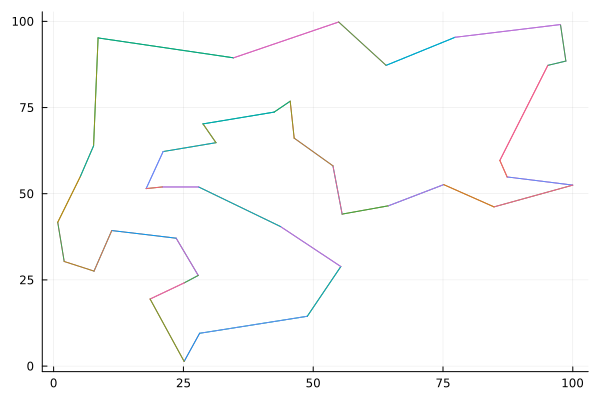

In [9]:
function plot_tour(X, Y, x)
    plot = Plots.plot()
    for (i, j) in selected_edges(x, size(x, 1))
        Plots.plot!([X[i], X[j]], [Y[i], Y[j]]; legend = false)
    end
    return plot
end

plot_tour(X, Y, value.(iterative_model[:x]))

### Lazy constraint method

A more sophisticated approach makes use of _lazy constraints_. To be more
precise, we do this through the `subtour_elimination_callback()` below, which
is only run whenever we encounter a new integer-feasible solution.

In [10]:
lazy_model = build_tsp_model(d, n)
function subtour_elimination_callback(cb_data)
    status = callback_node_status(cb_data, lazy_model)
    if status != MOI.CALLBACK_NODE_STATUS_INTEGER
        return  # Only run at integer solutions
    end
    cycle = subtour(callback_value.(cb_data, lazy_model[:x]))
    if !(1 < length(cycle) < n)
        return  # Only add a constraint if there is a cycle
    end
    println("Found cycle of length $(length(cycle))")
    S = [(i, j) for (i, j) in Iterators.product(cycle, cycle) if i < j]
    con = @build_constraint(
        sum(lazy_model[:x][i, j] for (i, j) in S) <= length(cycle) - 1,
    )
    MOI.submit(lazy_model, MOI.LazyConstraint(cb_data), con)
    return
end
set_attribute(
    lazy_model,
    MOI.LazyConstraintCallback(),
    subtour_elimination_callback,
)
optimize!(lazy_model)
@assert is_solved_and_feasible(lazy_model)
objective_value(lazy_model)

Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 4
Found cycle of length 5
Found cycle of length 3
Found cycle of length 4
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 4
Found cycle of length 5
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 4
Found cycle of length 3
Found cycle of length 4
Found cycle of length 4
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 4
Found cycle of length 5
Found cycle of length 3
Found cycle of length 5
Found cycle of length 3
Found cycle of length 4
Found cycle of length 4
Found cycle of length 5
Found cycle of length 3
Found cycle of length 5
Found cycle of length 4
Found cycle of length 5
Found cycle of length 3
Found cycle of length 3
Found cycle of length 3
Found cycle of length 5
Found cycle of length 4
Found cycle of length 4
Found cycle of length 4
Found cycle of l

525.7039004442727

This finds the same optimal tour:

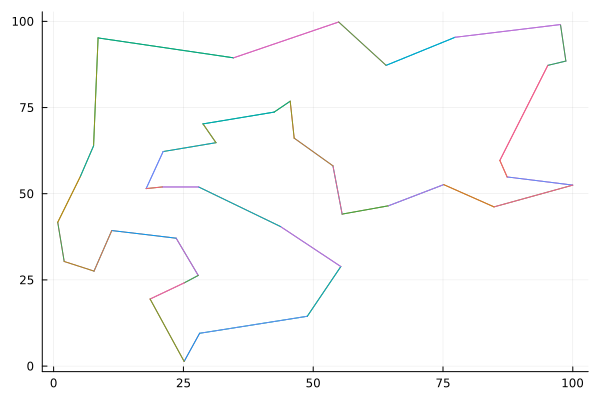

In [11]:
plot_tour(X, Y, value.(lazy_model[:x]))

Surprisingly, for this particular model with GLPK, the solution time is worse
than the iterative method:

In [12]:
time_lazy = solve_time(lazy_model)

0.27466392517089844

In most other cases and solvers, however, the lazy time should be faster than
the iterative method.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*